### 실습
- 오늘 배운 EDA 해보고, 무엇을 분석해보자 할지 생각하고 접근방법
- 시각화 해보고
- 다시 반복

#### 일단 데이터 분석 반복

In [63]:
import pandas as pd

In [64]:
camera_df = pd.read_csv("../data/CCTV_Seoul.csv", encoding="cp949")
# target_purposes = [
#       "기타",
#       "다목적",
#       "생활방범",
#       "시설물관리",
#       "어린이보호",
#       "차량방범",
#   ]

# camera_df = camera_df[camera_df["설치목적구분"].isin(target_purposes)]

camera_total = (
    camera_df
    .groupby("관리기관명", as_index=False)["카메라대수"]
    .sum()
    .assign(
        지역=lambda data: data["관리기관명"].str.replace(
            r"^(서울특별시|서울시)\s*|\s*청$",
            "",
            regex=True,
        )
    )
    [["지역", "카메라대수"]]
)

camera_total = camera_total.sort_values("지역").reset_index(drop=True)

camera_total.head()

,지역,카메라대수
0,강남구,8600
1,강동구,4237
2,강북구,4596
3,강서구,4735
4,관악구,6789


In [65]:
population_df = pd.read_csv("../data/population.csv")

# 동별(3)이 '소계'인 행만 구 단위 합계로 선택
gu_total = population_df.loc[
    population_df["동별(3)"] == "소계"
].copy()

# 두 번째 행에서 '소계'라고 표시된 열만 선택
subtotal_columns = population_df.columns[
    population_df.iloc[1] == "소계"
]

population_total = (
    gu_total.loc[:, subtotal_columns]
    .copy()
    .rename(
        columns=dict(
            zip(
                subtotal_columns,
                ["세대 총합", "인구 총합", "한국인 총합", "외국인 총합"],
            )
        )
    )
    .assign(지역=gu_total["동별(2)"].values)
    .query('지역 != "서울특별시"')
    [["지역", "인구 총합", "한국인 총합", "외국인 총합"]]
    .reset_index(drop=True)
)

population_total = population_total.drop(0)
population_total = population_total.sort_values("지역").reset_index(drop=True)
population_total.head()

,지역,인구 총합,한국인 총합,외국인 총합
0,강남구,558809,552631,6178
1,강동구,503495,498701,4794
2,강북구,285130,277695,7435
3,강서구,554922,548268,6654
4,관악구,497177,477503,19674


In [66]:
station_to_gu = {
    "강남": "강남구", "강동": "강동구", "강북": "강북구",
    "강서": "강서구", "관악": "관악구", "광진": "광진구",
    "구로": "구로구", "금천": "금천구", "남대문": "중구",
    "노원": "노원구", "도봉": "도봉구", "동대문": "동대문구",
    "동작": "동작구", "마포": "마포구", "방배": "서초구",
    "서대문": "서대문구", "서부": "은평구", "서초": "서초구",
    "성동": "성동구", "성북": "성북구", "송파": "송파구",
    "수서": "강남구", "양천": "양천구", "영등포": "영등포구",
    "용산": "용산구", "은평": "은평구", "종로": "종로구",
    "종암": "성북구", "중랑": "중랑구", "중부": "중구",
    "혜화": "종로구",
}

In [67]:
crime_df = pd.read_csv("../data/crime_fixed.csv", encoding="utf-8-sig")

crime_total = (
    crime_df
    .query('발생검거 == "발생"')
    .assign(지역=lambda data: data["구분"].map(station_to_gu))
    .dropna(subset=["지역"])
    .groupby("지역", as_index=False)["건수"]
    .sum()
)

crime_total.head()

,지역,건수
0,강남구,6107
1,강동구,3350
2,강북구,2289
3,강서구,4008
4,관악구,4485


In [68]:
print(population_total.columns)
print(camera_total.columns)
print(crime_total.columns)

Index(['지역', '인구 총합', '한국인 총합', '외국인 총합'], dtype='str')
Index(['지역', '카메라대수'], dtype='str')
Index(['지역', '건수'], dtype='str')


In [69]:
total_df = pd.merge(
      population_total,
      camera_total,
      on="지역",
      how="left"
  )

final_df = pd.merge(
      total_df,
      crime_total,
      on="지역",
      how="left"
  )
final_df.head()

,지역,인구 총합,한국인 총합,외국인 총합,카메라대수,건수
0,강남구,558809,552631,6178,8600,6107
1,강동구,503495,498701,4794,4237,3350
2,강북구,285130,277695,7435,4596,2289
3,강서구,554922,548268,6654,4735,4008
4,관악구,497177,477503,19674,6789,4485


In [70]:
columns = ["인구 총합", "한국인 총합", "외국인 총합"]

analysis_df = final_df.copy()
analysis_df[columns] = analysis_df[columns].apply(pd.to_numeric)

analysis_df['인구 1만명당 카메라 수'] = analysis_df['카메라대수'] / analysis_df['인구 총합'] * 10000
analysis_df['인구 1만명당 범죄 건수'] = analysis_df['건수'] / analysis_df['인구 총합'] * 10000
analysis_df.head()

,지역,인구 총합,한국인 총합,외국인 총합,카메라대수,건수,인구 1만명당 카메라 수,인구 1만명당 범죄 건수
0,강남구,558809,552631,6178,8600,6107,153.898738,109.285999
1,강동구,503495,498701,4794,4237,3350,84.151779,66.534921
2,강북구,285130,277695,7435,4596,2289,161.189633,80.279171
3,강서구,554922,548268,6654,4735,4008,85.327307,72.226367
4,관악구,497177,477503,19674,6789,4485,136.550967,90.209322


#### 시각 분석 시작

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px     # 실제로 가장 많이 사용
import plotly.graph_objects as go # 그래프 생성의 세세한 부분까지 다 제어가능

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

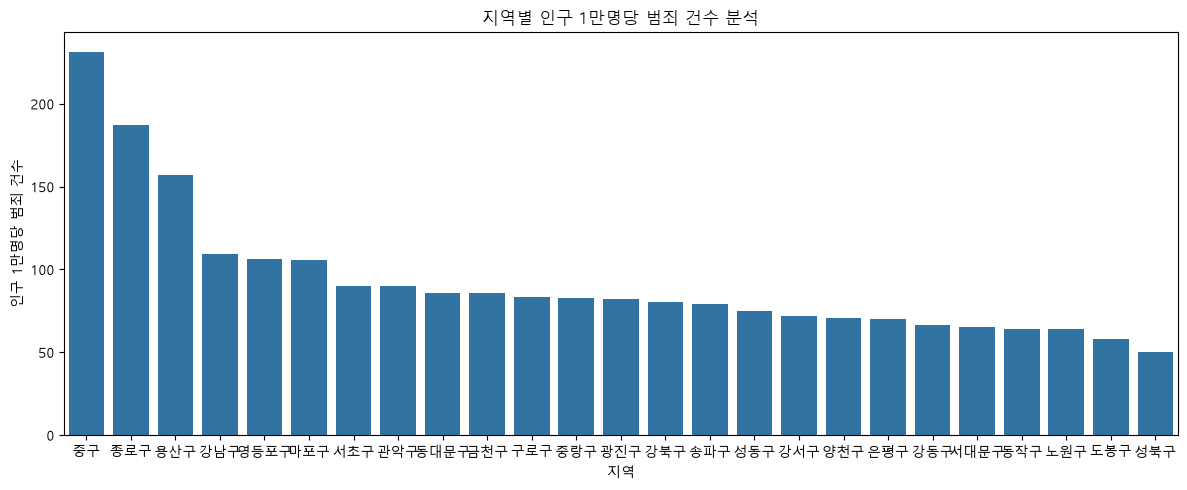

In [72]:
# 1: 인구 1만명 당 범죄 건수 막대그래프

plt.figure(figsize=(12, 5))
crime_order = (
      analysis_df
      .sort_values("인구 1만명당 범죄 건수", ascending=False)["지역"]
  )

sns.barplot(data=analysis_df,
            x="지역",
            y="인구 1만명당 범죄 건수",
            order=crime_order)

plt.title("지역별 인구 1만명당 범죄 건수 분석")
plt.tight_layout()
plt.show()

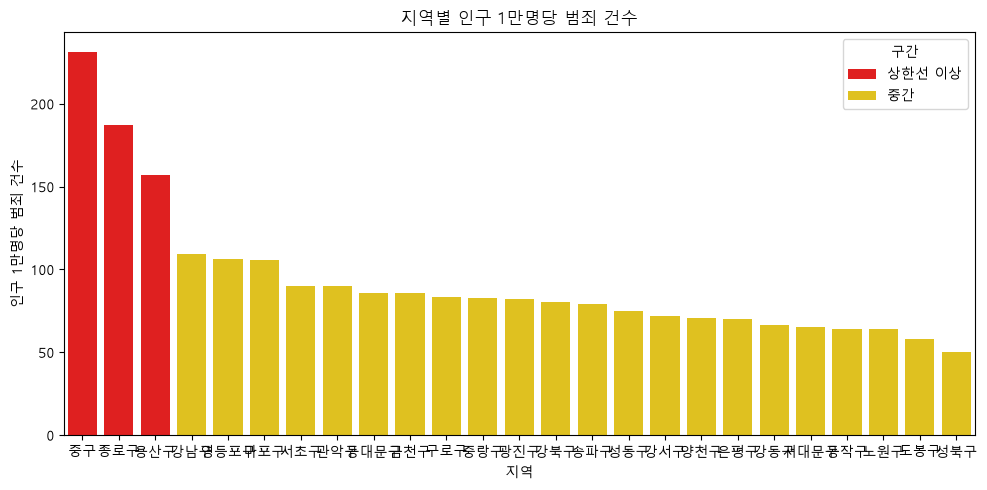

In [86]:
rate_col = "인구 1만명당 범죄 건수"

# top_limit = analysis_df[rate_col].quantile(0.9)
# bottom_limit = analysis_df[rate_col].quantile(0.1)

Q3 = analysis_df[rate_col].quantile(0.75)
Q1 = analysis_df[rate_col].quantile(0.25)
IQR = (Q3 - Q1)

top_limit = Q3 + 1.5*IQR
bottom_limit = Q1 - 1.5*IQR

plot_df = analysis_df[["지역", rate_col]].copy()

def make_group(rate):
    if rate >= top_limit:
        return "상한선 이상"
    elif rate <= bottom_limit:
        return "하한선 이하"
    return "중간"

plot_df["구간"] = plot_df[rate_col].apply(make_group)

plot_df = plot_df.sort_values(rate_col, ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=plot_df,
    x="지역",
    y=rate_col,
    hue="구간",
    palette={
        "상한선 이상": "red",
        "중간": "gold",
        "하한선 이하": "green",
    },
)

plt.title("지역별 인구 1만명당 범죄 건수")
plt.tight_layout()
plt.show()

In [74]:
fig = px.scatter(data_frame=analysis_df,
                 x="인구 1만명당 카메라 수",
                 y="인구 1만명당 범죄 건수",
                 trendline="ols",
                title="카메라 수와 범죄 건수 상관관계 분석",
                hover_data="지역")

fig.show()

In [75]:
analysis_df['외국인 비율'] = analysis_df['외국인 총합'] / analysis_df['인구 총합']
analysis_df.head()

,지역,인구 총합,한국인 총합,외국인 총합,카메라대수,건수,인구 1만명당 카메라 수,인구 1만명당 범죄 건수,외국인 비율
0,강남구,558809,552631,6178,8600,6107,153.898738,109.285999,0.011056
1,강동구,503495,498701,4794,4237,3350,84.151779,66.534921,0.009521
2,강북구,285130,277695,7435,4596,2289,161.189633,80.279171,0.026076
3,강서구,554922,548268,6654,4735,4008,85.327307,72.226367,0.011991
4,관악구,497177,477503,19674,6789,4485,136.550967,90.209322,0.039571


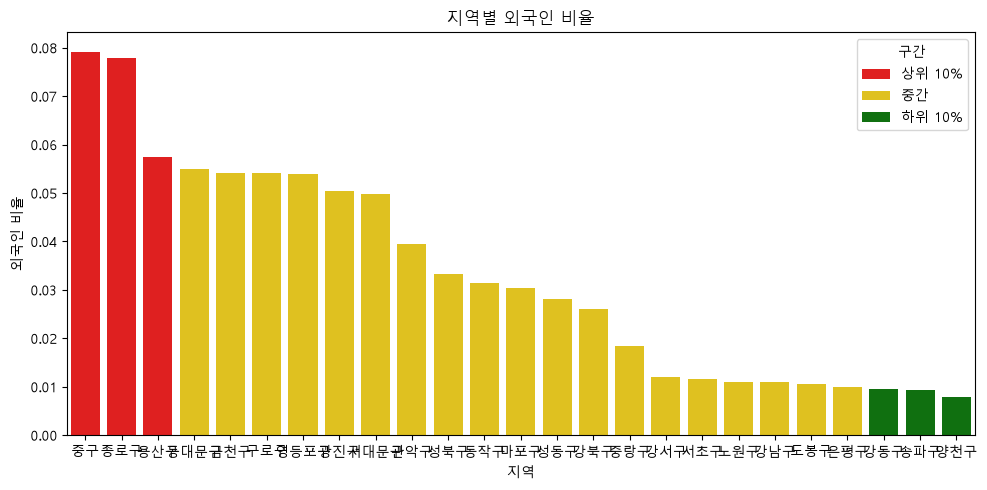

In [87]:
rate_col = "외국인 비율"

top_limit = analysis_df[rate_col].quantile(0.9)
bottom_limit = analysis_df[rate_col].quantile(0.1)

# Q3 = analysis_df[rate_col].quantile(0.75)
# Q1 = analysis_df[rate_col].quantile(0.25)
# IQR = (Q3 - Q1)

# top_limit = Q3 + 1.5*IQR
# bottom_limit = Q1 - 1.5*IQR

plot_df = analysis_df[["지역", rate_col]].copy()

def make_group(rate):
    if rate >= top_limit:
        return "상위 10%"
    elif rate <= bottom_limit:
        return "하위 10%"
    return "중간"

plot_df["구간"] = plot_df[rate_col].apply(make_group)

plot_df = plot_df.sort_values(rate_col, ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=plot_df,
    x="지역",
    y=rate_col,
    hue="구간",
    palette={
        "상위 10%": "red",
        "중간": "gold",
        "하위 10%": "green",
    },
)

plt.title("지역별 외국인 비율")
plt.tight_layout()
plt.show()

In [88]:
fig = px.scatter(data_frame=analysis_df,
                 x="외국인 비율",
                 y="인구 1만명당 범죄 건수",
                 trendline="ols",
                title="외국인 비율과 범죄 건수 상관관계 분석",
                hover_data="지역")

fig.show()